# SVM Model v02 for Medical Specialty Classification
This notebook trains and evaluates two SVM models using the **EDA-filtered dataset** from `model.ipynb`.

Key improvements over v01:
1. **Biological Filtering**: We filter the dataset to 4 distinct biological systems (Cardiovascular, Neurology, Obstetrics/Gynecology, Gastroenterology) instead of using all ~40 specialties.
2. **Cleaned Features**: The `extracted_features` column is cleaned of brackets, quotes, and commas.
3. **Consistent Preprocessing**: Data loading, cleaning, and filtering logic matches `model.ipynb`.

We compare two feature sets:
1. **Model 1**: Uses only the `transcription` feature.
2. **Model 2**: Uses a combination of `transcription`, `keywords`, and `clean_features`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================================
# Data Loading & Preprocessing (matching model.ipynb EDA logic)
# ============================================================

# 1. Load the dataset
print("Loading preprocessed dataset...")
df = pd.read_csv("processed_clinical_data.csv")
print(f"Original dataset shape: {df.shape}")

# 2. Drop rows missing extracted_features or medical_specialty
df = df.dropna(subset=['extracted_features', 'medical_specialty'])
df['medical_specialty'] = df['medical_specialty'].str.strip()

# 3. Define target biological systems (from model.ipynb EDA)
target_classes = [
    'Cardiovascular / Pulmonary',
    'Neurology',
    'Obstetrics / Gynecology',
    'Gastroenterology'
]

# 4. Filter the dataframe to only include target classes
df_filtered = df[df['medical_specialty'].isin(target_classes)].copy()

# 5. Clean the feature strings
df_filtered['clean_features'] = df_filtered['extracted_features'].str.replace(r"[\[\]',]", "", regex=True)

# 6. Handle missing values in text columns
text_cols = ['transcription', 'keywords', 'clean_features']
for col in text_cols:
    df_filtered[col] = df_filtered[col].fillna('')

# 7. Create feature columns
# Model 1: transcription only
df_filtered['text_basic'] = df_filtered['transcription']
# Model 2: combined (transcription + keywords + clean_features)
df_filtered['text_combined'] = df_filtered['transcription'] + " " + df_filtered['keywords'] + " " + df_filtered['clean_features']

print(f"Filtered dataset shape: {df_filtered.shape}")
print("\n--- Filtered Dataset Class Distribution ---")
print(df_filtered['medical_specialty'].value_counts())
print(f"\nTotal patient notes: {len(df_filtered)}")

df_filtered.head()

Loading preprocessed dataset...
Original dataset shape: (4966, 7)
Filtered dataset shape: (973, 10)

--- Filtered Dataset Class Distribution ---
medical_specialty
Cardiovascular / Pulmonary    371
Gastroenterology              224
Neurology                     223
Obstetrics / Gynecology       155
Name: count, dtype: int64

Total patient notes: 973


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords,extracted_features,clean_features,text_basic,text_combined
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...","['C1705052', 'C0238705', 'C1182755', 'cm.,2. N...",C1705052 C0238705 C1182755 cm.2. Normal size r...,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...","['C0455830', 'C0677535', 'C1980023', 'C0080310...",C0455830 C0677535 C1980023 C0080310 C0489482 C...,1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...
7,7,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 3,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","cardiovascular / pulmonary, 2-d echocardiogram...","['C0013516', 'C0225991', 'C0729936', 'C0232164...",C0013516 C0225991 C0729936 C0232164 Doppler in...,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","2-D ECHOCARDIOGRAM,Multiple views of the heart..."
9,9,Echocardiogram and Doppler,Cardiovascular / Pulmonary,2-D Echocardiogram - 4,"DESCRIPTION:,1. Normal cardiac chambers size....","cardiovascular / pulmonary, ejection fraction,...","['C0729936', 'C1277187', 'C0003501', 'C0026264...",C0729936 C1277187 C0003501 C0026264 C0040960 C...,"DESCRIPTION:,1. Normal cardiac chambers size....","DESCRIPTION:,1. Normal cardiac chambers size...."
11,11,"Normal left ventricle, moderate biatrial enla...",Cardiovascular / Pulmonary,2-D Doppler,"2-D STUDY,1. Mild aortic stenosis, widely calc...","cardiovascular / pulmonary, 2-d study, doppler...","['C0003507', 'C5395243', 'systolic function.,3...",C0003507 C5395243 systolic function.3 C0225897...,"2-D STUDY,1. Mild aortic stenosis, widely calc...","2-D STUDY,1. Mild aortic stenosis, widely calc..."


In [4]:
# Define features and target
X_basic = df_filtered['text_basic']
X_combined = df_filtered['text_combined']
y = df_filtered['medical_specialty']

# Split for Model 1 (80% train, 20% test)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

# Split for Model 2 (Using exactly the same indices)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train_b.shape[0]}")
print(f"Testing samples: {X_test_b.shape[0]}")

Training samples: 778
Testing samples: 195


In [5]:
# --- MODEL 1: Basic Features (transcription only) ---

pipeline_b = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

# Define parameter grid for Grid Search
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

# GridSearchCV with 5-fold cross validation on the training data
grid_b = GridSearchCV(pipeline_b, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 1 (Basic Text) with GridSearchCV...")
grid_b.fit(X_train_b, y_train_b)

print(f"\nBest Parameters for Model 1: {grid_b.best_params_}")
print(f"Best CV Accuracy (Model 1): {grid_b.best_score_:.4f}")

Training Model 1 (Basic Text) with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters for Model 1: {'svm__C': 1, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 1): 0.9395


Classification Report - Model 1 (Basic Text):

                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.89      0.95      0.92        74
          Gastroenterology       0.97      0.84      0.90        45
                 Neurology       0.93      0.96      0.95        45
   Obstetrics / Gynecology       0.97      0.97      0.97        31

                  accuracy                           0.93       195
                 macro avg       0.94      0.93      0.93       195
              weighted avg       0.93      0.93      0.93       195



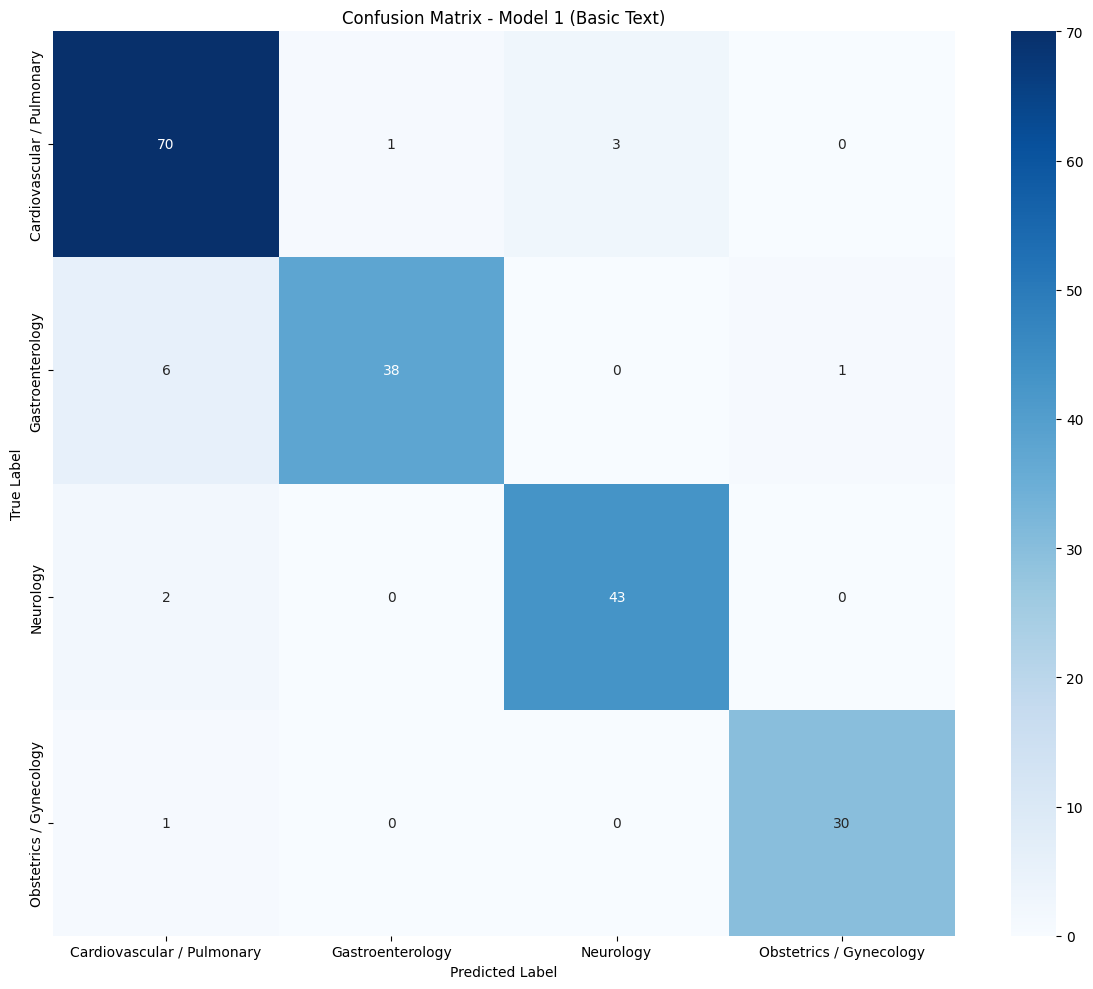

In [6]:
# Evaluate Model 1 on the hold-out test set
y_pred_b = grid_b.predict(X_test_b)

print("Classification Report - Model 1 (Basic Text):\n")
print(classification_report(y_test_b, y_pred_b, zero_division=0))

# Confusion Matrix for Model 1
plt.figure(figsize=(12, 10))
cm_b = confusion_matrix(y_test_b, y_pred_b)
sns.heatmap(cm_b, annot=True, cmap="Blues", fmt='d',
            xticklabels=grid_b.best_estimator_.classes_,
            yticklabels=grid_b.best_estimator_.classes_)
plt.title("Confusion Matrix - Model 1 (Basic Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [7]:
# --- MODEL 2: Combined Features (transcription + keywords + clean_features) ---

pipeline_c = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('svm', SVC(random_state=42))
])

grid_c = GridSearchCV(pipeline_c, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Training Model 2 (Combined Text) with GridSearchCV...")
grid_c.fit(X_train_c, y_train_c)

print(f"\nBest Parameters for Model 2: {grid_c.best_params_}")
print(f"Best CV Accuracy (Model 2): {grid_c.best_score_:.4f}")

Training Model 2 (Combined Text) with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters for Model 2: {'svm__C': 10, 'svm__kernel': 'linear'}
Best CV Accuracy (Model 2): 0.9524


Classification Report - Model 2 (Combined Text):

                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.88      0.95      0.91        74
          Gastroenterology       0.97      0.84      0.90        45
                 Neurology       0.91      0.96      0.93        45
   Obstetrics / Gynecology       1.00      0.94      0.97        31

                  accuracy                           0.92       195
                 macro avg       0.94      0.92      0.93       195
              weighted avg       0.93      0.92      0.92       195



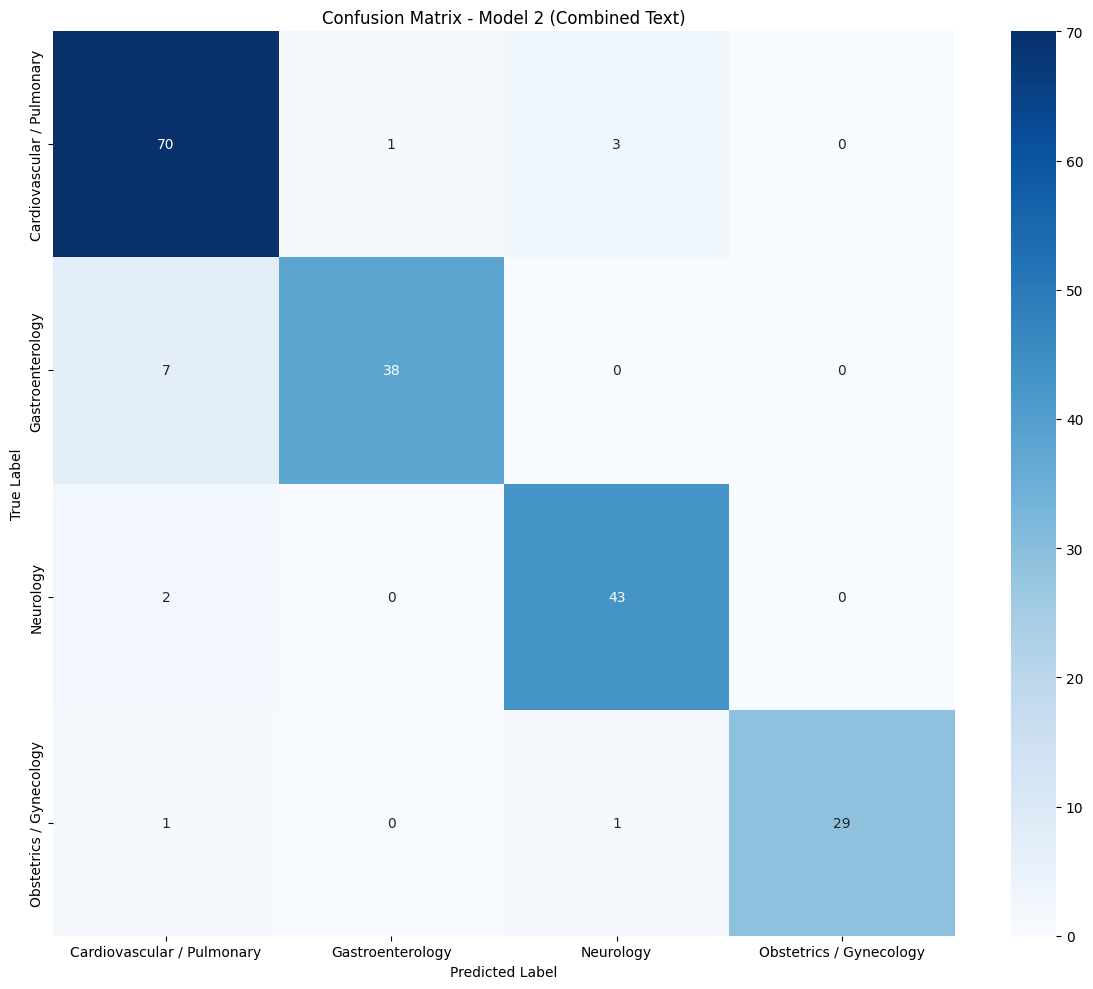

In [8]:
# Evaluate Model 2 on the hold-out test set
y_pred_c = grid_c.predict(X_test_c)

print("Classification Report - Model 2 (Combined Text):\n")
print(classification_report(y_test_c, y_pred_c, zero_division=0))

# Confusion Matrix for Model 2
plt.figure(figsize=(12, 10))
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, cmap="Blues", fmt='d',
            xticklabels=grid_c.best_estimator_.classes_,
            yticklabels=grid_c.best_estimator_.classes_)
plt.title("Confusion Matrix - Model 2 (Combined Text)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

## Additional Evaluation Metrics

### ROC Curve (Applicable ✅)
The **ROC (Receiver Operating Characteristic) curve** is a standard evaluation metric for classification tasks. Since this is a **multi-class** classification problem (4 medical specialties), we use the **One-vs-Rest (OvR)** approach to compute a ROC curve for each class separately. The AUC (Area Under the Curve) summarizes each curve into a single number — the closer to 1.0, the better the classifier.

### RMSE / MSE (Not Applicable ❌)
**RMSE (Root Mean Squared Error)** and **MSE (Mean Squared Error)** are **regression metrics**. They measure the magnitude of continuous prediction errors (i.e., the difference between a predicted numerical value and the true numerical value). Since our task is **multi-class classification** — predicting discrete categorical labels (medical specialties), not continuous values — RMSE and MSE are **not meaningful** here and are therefore excluded.

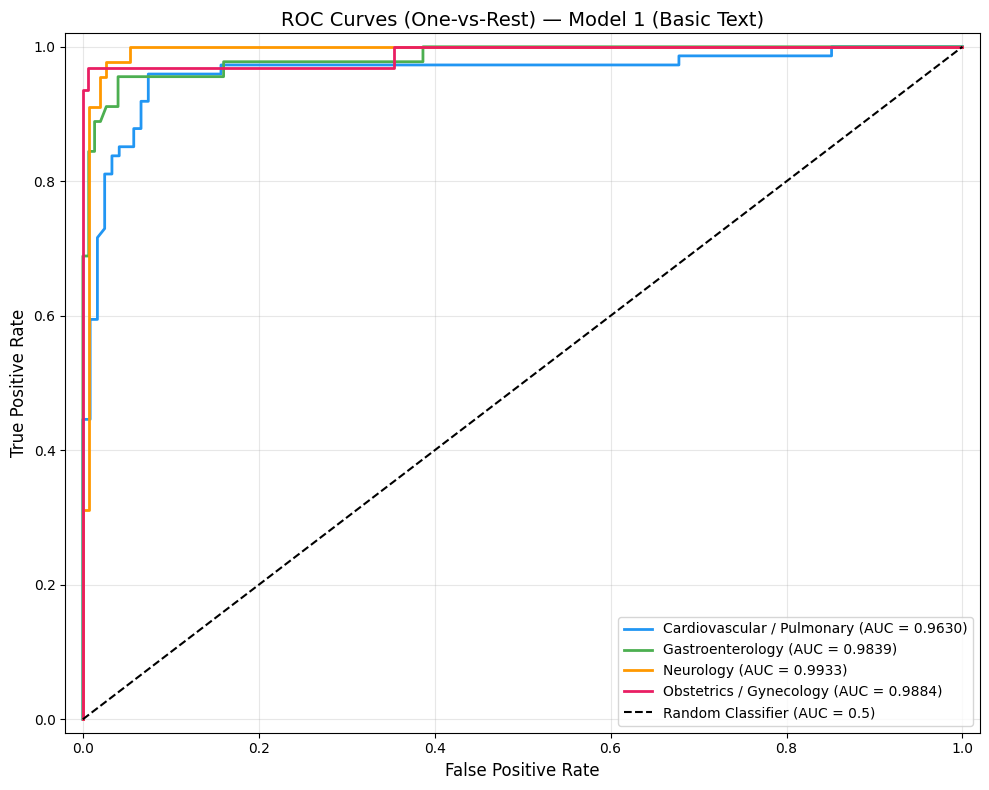


--- AUC Summary for Model 1 (Basic Text) ---
  Cardiovascular / Pulmonary: AUC = 0.9630
  Gastroenterology: AUC = 0.9839
  Neurology: AUC = 0.9933
  Obstetrics / Gynecology: AUC = 0.9884
  Macro-Average AUC: 0.9822


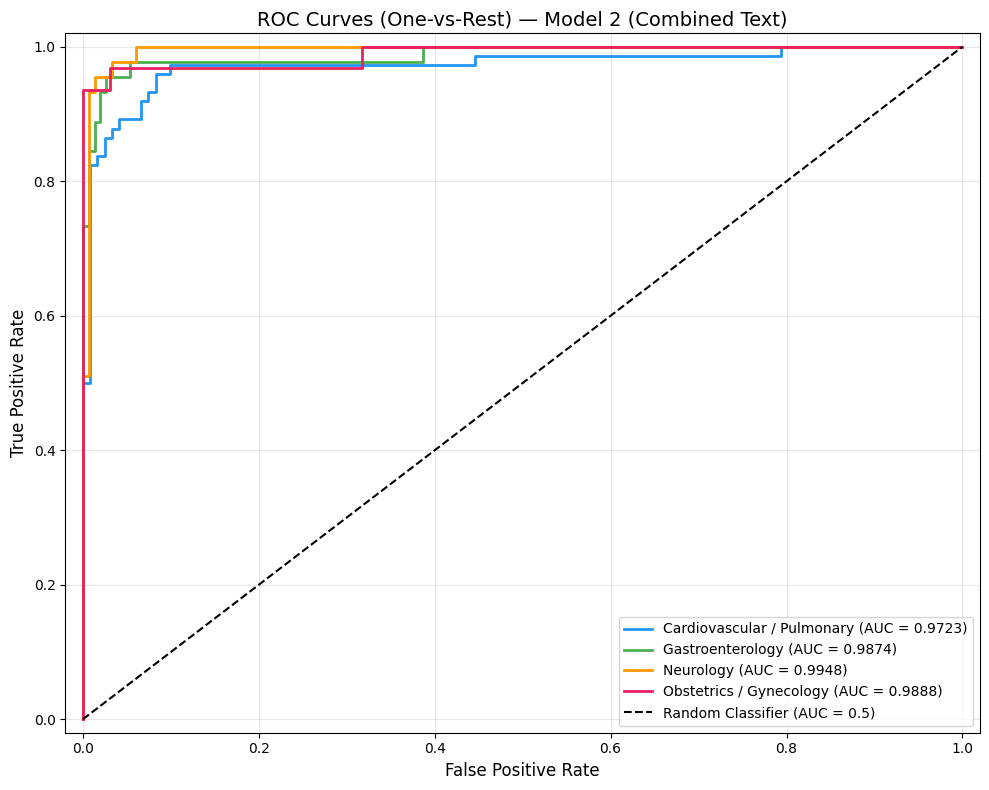


--- AUC Summary for Model 2 (Combined Text) ---
  Cardiovascular / Pulmonary: AUC = 0.9723
  Gastroenterology: AUC = 0.9874
  Neurology: AUC = 0.9948
  Obstetrics / Gynecology: AUC = 0.9888
  Macro-Average AUC: 0.9858


In [9]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# --- Helper function to plot multi-class ROC curves ---
def plot_multiclass_roc(grid_model, X_test, y_test, model_name):
    """
    Plot One-vs-Rest ROC curves for a multi-class SVM classifier.
    Uses decision_function scores as the ranking metric.
    """
    classes = grid_model.best_estimator_.classes_
    n_classes = len(classes)

    # Binarize the true labels: shape (n_samples, n_classes)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Get decision function scores: shape (n_samples, n_classes)
    y_score = grid_model.decision_function(X_test)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot
    plt.figure(figsize=(10, 8))
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], lw=2,
                 label=f'{classes[i]} (AUC = {roc_auc[i]:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves (One-vs-Rest) — {model_name}', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print summary
    print(f'\n--- AUC Summary for {model_name} ---')
    for i in range(n_classes):
        print(f'  {classes[i]}: AUC = {roc_auc[i]:.4f}')
    macro_auc = np.mean(list(roc_auc.values()))
    print(f'  Macro-Average AUC: {macro_auc:.4f}')


# --- ROC Curve for Model 1 (Basic Text) ---
plot_multiclass_roc(grid_b, X_test_b, y_test_b, 'Model 1 (Basic Text)')

# --- ROC Curve for Model 2 (Combined Text) ---
plot_multiclass_roc(grid_c, X_test_c, y_test_c, 'Model 2 (Combined Text)')

In [ ]:
# Save models to disk
joblib.dump(grid_b.best_estimator_, 'svm_model_v02_basic.pkl')
joblib.dump(grid_c.best_estimator_, 'svm_model_v02_combined.pkl')
print("Models saved successfully to disk (svm_model_v02_basic.pkl, svm_model_v02_combined.pkl).")

## Additional Models: PCA and RFE Comparison
We will now compare the base models with dimensionality reduction techniques (PCA via TruncatedSVD and Backward Elimination via RFE).


### 1. Model 1: Basic Features + PCA (TruncatedSVD)


In [ ]:
# --- MODEL 1 + PCA ---
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report

# We use best parameters typically found (C=1.0, kernel='linear') for the baseline SVM
pipeline_b_pca = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('pca', TruncatedSVD(n_components=300, random_state=42)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 1 (Basic Text) + PCA...")
pipeline_b_pca.fit(X_train_b, y_train_b)
y_pred_b_pca = pipeline_b_pca.predict(X_test_b)

print("\nClassification Report - Model 1 + PCA:")
print(classification_report(y_test_b, y_pred_b_pca, zero_division=0))


### 2. Model 1: Basic Features + RFE (Backward Elimination)
> Note: We reduce the TF-IDF `max_features` to 1000 for RFE to ensure it runs in a reasonable amount of time. Running RFE on 10,000 features is extremely computationally expensive.


In [ ]:
# --- MODEL 1 + RFE ---
from sklearn.feature_selection import RFE

pipeline_b_rfe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=1000, sublinear_tf=True)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42), n_features_to_select=100, step=0.1)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 1 (Basic Text) + RFE...")
pipeline_b_rfe.fit(X_train_b, y_train_b)
y_pred_b_rfe = pipeline_b_rfe.predict(X_test_b)

print("\nClassification Report - Model 1 + RFE:")
print(classification_report(y_test_b, y_pred_b_rfe, zero_division=0))


### 3. Model 2: Combined Features + PCA (TruncatedSVD)


In [ ]:
# --- MODEL 2 + PCA ---

pipeline_c_pca = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=10000, sublinear_tf=True)),
    ('pca', TruncatedSVD(n_components=300, random_state=42)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 2 (Combined Text) + PCA...")
pipeline_c_pca.fit(X_train_c, y_train_c)
y_pred_c_pca = pipeline_c_pca.predict(X_test_c)

print("\nClassification Report - Model 2 + PCA:")
print(classification_report(y_test_c, y_pred_c_pca, zero_division=0))


### 4. Model 2: Combined Features + RFE (Backward Elimination)


In [ ]:
# --- MODEL 2 + RFE ---

pipeline_c_rfe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 3), max_features=1000, sublinear_tf=True)),
    ('rfe', RFE(estimator=LinearSVC(random_state=42), n_features_to_select=100, step=0.1)),
    ('svm', SVC(C=1.0, kernel='linear', random_state=42))
])

print("Training Model 2 (Combined Text) + RFE...")
pipeline_c_rfe.fit(X_train_c, y_train_c)
y_pred_c_rfe = pipeline_c_rfe.predict(X_test_c)

print("\nClassification Report - Model 2 + RFE:")
print(classification_report(y_test_c, y_pred_c_rfe, zero_division=0))
